In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

In [5]:
## Definicion de la arquitectura del modelo
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(28*28, 20) #hidden layer 1
        self.relu = nn.ReLU() #funcion de activacion relu
        self.fc2 = nn.Linear(20, 10)  #hidden layer 2
        self.softmax = nn.Sigmoid()
    
    def forward(self, x):
        x = x.view(-1, 28*28) #el -1 hace que esa primera dimension se autoajuste en funcion de las otras
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x


In [6]:
# Carga de los datos
transform = transforms.ToTensor()
train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

In [25]:
# Procesado de los datos
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=True)

In [16]:
# Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = NeuralNetwork().to(device)

In [26]:
# Optimozador y funcion de perdida
optimizer = optim.Adam(network.parameters(), lr=0.01, betas=(0.9, 0.99))
loss_criterion = nn.CrossEntropyLoss()

In [ ]:
# Funcion de entrenamiento
def train(network, device, train_loader, optimizer, epoch):
    network.train()
    for batch_id, (data, label) in enumerate(train_loader):
        data, label = data.to(device), label.to(device)
        optimizer.zero_grad()
        output = network(data)
        loss = loss_criterion(output, label)
        loss.backward()
        optimizer.step()
        if batch_id % 100 == 0:
            print(f"Epoch {epoch} [{batch_id * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item():6f}")

In [36]:
# Funcion de testeo
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_criterion(output, target).item()  # Suma de la pérdida
            pred = output.argmax(dim=1, keepdim=True)        # Predicción: índice de la clase mayor probabilidad
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    accuaracy = 100. * correct / len(test_loader.dataset)
    print(f"\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n")
    return accuaracy

In [61]:
epochs = 3
model_precision = torch.zeros(epochs)
epochs_vect = torch.zeros(epochs)
print(model_precision)

tensor([0., 0., 0.])


In [ ]:
for epoch in range(1, epochs+1):
    train(network, device, train_loader, optimizer, epoch)
    print(epoch)
    model_precision[epoch-1] = test(network, device, test_loader)
    epochs_vect[epoch-1] = epoch
    print(model_precision)  


Epoch 1 [0/60000] Loss: 1.486353
Epoch 1 [6400/60000] Loss: 1.485280
Epoch 1 [12800/60000] Loss: 1.519909
Epoch 1 [19200/60000] Loss: 1.487435
Epoch 1 [25600/60000] Loss: 1.551583
Epoch 1 [32000/60000] Loss: 1.491574
Epoch 1 [38400/60000] Loss: 1.484137
Epoch 1 [44800/60000] Loss: 1.492733
Epoch 1 [51200/60000] Loss: 1.484950
Epoch 1 [57600/60000] Loss: 1.566731
1

Test set: Average loss: 0.0238, Accuracy: 9305/10000 (93%)

tensor([1., 0., 0.])
Epoch 2 [0/60000] Loss: 1.505109
Epoch 2 [6400/60000] Loss: 1.489143
Epoch 2 [12800/60000] Loss: 1.513777
Epoch 2 [19200/60000] Loss: 1.519015
Epoch 2 [25600/60000] Loss: 1.511606
Epoch 2 [32000/60000] Loss: 1.478255
Epoch 2 [38400/60000] Loss: 1.509366
Epoch 2 [44800/60000] Loss: 1.526825
Epoch 2 [51200/60000] Loss: 1.500893
Epoch 2 [57600/60000] Loss: 1.558109
2

Test set: Average loss: 0.0238, Accuracy: 9296/10000 (93%)

tensor([1., 2., 0.])
Epoch 3 [0/60000] Loss: 1.500612
Epoch 3 [6400/60000] Loss: 1.525761
Epoch 3 [12800/60000] Loss: 1.538

In [52]:
print(model_precision[:,0])
print(model_precision[:,1])

tensor([1., 2., 3.])
tensor([92.9600, 92.6400, 93.4600])


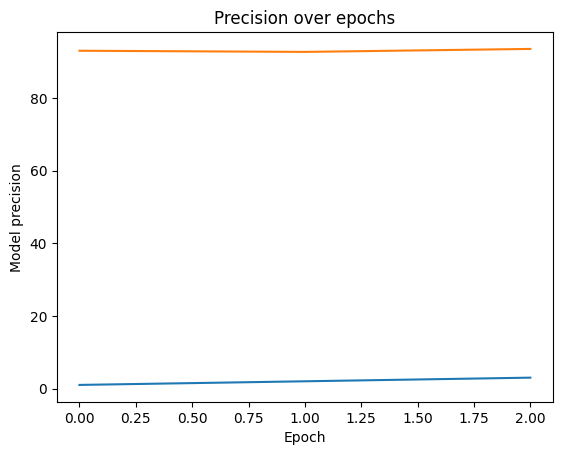

In [59]:
import matplotlib.pyplot as plt

plt.plot(model_precision)
plt.xlabel("Epoch")
plt.ylabel("Model precision")
plt.title("Precision over epochs")
plt.show()